In [1]:
# Cell 0 - Colab setup & mounts

# --- 1. Install required libraries ---
# Using -q for a quieter installation
!pip install -q timm nibabel scikit-image grad-cam matplotlib torchsummary

# --- 2. Import necessary libraries ---
import os
import random
import numpy as np
import torch
from google.colab import drive

# --- 3. Set seeds for reproducibility ---
def set_seed(seed=42):
    """Sets the seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.
        # The following two lines are known to slow down training, but ensure reproducibility
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed}")

set_seed(42)

# --- 4. Mount Google Drive ---
# This will prompt for authorization.
try:
    drive.mount('/content/drive')
    print("Google Drive mounted successfully!")
except Exception as e:
    print(f"Error mounting Google Drive: {e}")

# --- 5. Verify library installations (optional) ---
print("\nVerifying library installations...")
try:
    import timm
    import nibabel
    import skimage
    import grad_cam
    import torchsummary
    print("All libraries seem to be installed correctly.")
except ImportError as e:
    print(f"There was an error importing a library: {e}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 93.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Random seed set to 42
Mounted at /content/drive
Google Drive mounted successfully!

Verifying library installations...
There was an error importing a library: No module named 'grad_cam'


In [3]:
# Cell 1 - Download / link datasets (Corrected & Debugged)

import os
import json

# --- 1. Configure Kaggle API ---
# This section assumes you have uploaded your 'kaggle.json' file to a 'Kaggle' folder in your Google Drive.

# Define the path to the Kaggle API key in Google Drive
drive_kaggle_path = '/content/drive/MyDrive/Kaggle/kaggle.json'
colab_kaggle_dir = '/root/.kaggle' # Corrected to /root/.kaggle for better compatibility
colab_kaggle_path = os.path.join(colab_kaggle_dir, 'kaggle.json')

print("--- Step 1: Checking for kaggle.json in Google Drive ---")
if not os.path.exists(drive_kaggle_path):
    print(f"ERROR: 'kaggle.json' not found at the specified Google Drive path: {drive_kaggle_path}")
    print("Please upload your Kaggle API token to that exact location and try again.")
else:
    print("Found kaggle.json in Google Drive. Proceeding with setup.")
    # Create the .kaggle directory in Colab's content folder
    os.makedirs(colab_kaggle_dir, exist_ok=True)
    # Copy the API key from Drive to Colab
    !cp {drive_kaggle_path} {colab_kaggle_path}
    # Set the correct permissions for the file
    !chmod 600 {colab_kaggle_path}

    print("\n--- Step 2: Verifying the copied kaggle.json file ---")
    if os.path.exists(colab_kaggle_path) and os.path.getsize(colab_kaggle_path) > 0:
        print("Kaggle API token copied and permissions set successfully.")
        # Optional: Print file content to verify it's not empty
        print("Content of kaggle.json:")
        with open(colab_kaggle_path, 'r') as f:
            try:
                content = json.load(f)
                print(f"  - Username: {content.get('username')}")
                print("  - Key: ****** (hidden for security)")
            except json.JSONDecodeError:
                print("  ERROR: The kaggle.json file is not valid JSON.")

        # --- 3. Download the primary dataset ---
        print("\n--- Step 3: Downloading the dataset ---")
        print("Downloading the primary dataset: Brain Tumor MRI Dataset (7k+ images)...")
        # The -p flag specifies the path to download the dataset to.
        # The --unzip flag automatically unzips the file.
        # The -q flag makes the download process quiet.
        !kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p /content/datasets/brain_tumor_7k --unzip -q

        print("Dataset download command executed.")

        # --- 4. Verify the download ---
        print("\n--- Step 4: Verifying downloaded content ---")
        dataset_path = '/content/datasets/brain_tumor_7k'
        if os.path.exists(dataset_path) and len(os.listdir(dataset_path)) > 0:
             print("Dataset successfully downloaded and unzipped to '/content/datasets/brain_tumor_7k'")
             !ls -R {dataset_path} | head -n 15 # List the first 15 lines of the directory structure
        else:
             print("ERROR: Dataset directory is empty or does not exist. The download may have failed.")
             print("Please check the output above for any Kaggle CLI errors.")

    else:
        print("ERROR: Failed to copy kaggle.json from Google Drive or the file is empty.")

--- Step 1: Checking for kaggle.json in Google Drive ---
Found kaggle.json in Google Drive. Proceeding with setup.

--- Step 2: Verifying the copied kaggle.json file ---
Kaggle API token copied and permissions set successfully.
Content of kaggle.json:
  - Username: jaisalsharma
  - Key: ****** (hidden for security)

--- Step 3: Downloading the dataset ---
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
Dataset download command executed.

--- Step 4: Verifying downloaded content ---
Dataset successfully downloaded and unzipped to '/content/datasets/brain_tumor_7k'
/content/datasets/brain_tumor_7k:
Testing
Training

/content/datasets/brain_tumor_7k/Testing:
glioma
meningioma
notumor
pituitary

/content/datasets/brain_tumor_7k/Testing/glioma:
Te-gl_0010.jpg
Te-gl_0011.jpg
Te-gl_0012.jpg
Te-gl_0013.jpg


--- Analyzing Training Data ---
Exploring directory: /content/datasets/brain_tumor_7k/Training
Found 4 classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
- Class 'glioma': 1321 images
- Class 'meningioma': 1339 images
- Class 'notumor': 1595 images
- Class 'pituitary': 1457 images

--- Analyzing Testing Data ---
Exploring directory: /content/datasets/brain_tumor_7k/Testing
Found 4 classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
- Class 'glioma': 300 images
- Class 'meningioma': 306 images
- Class 'notumor': 405 images
- Class 'pituitary': 300 images

--- Visualizing Training Samples ---


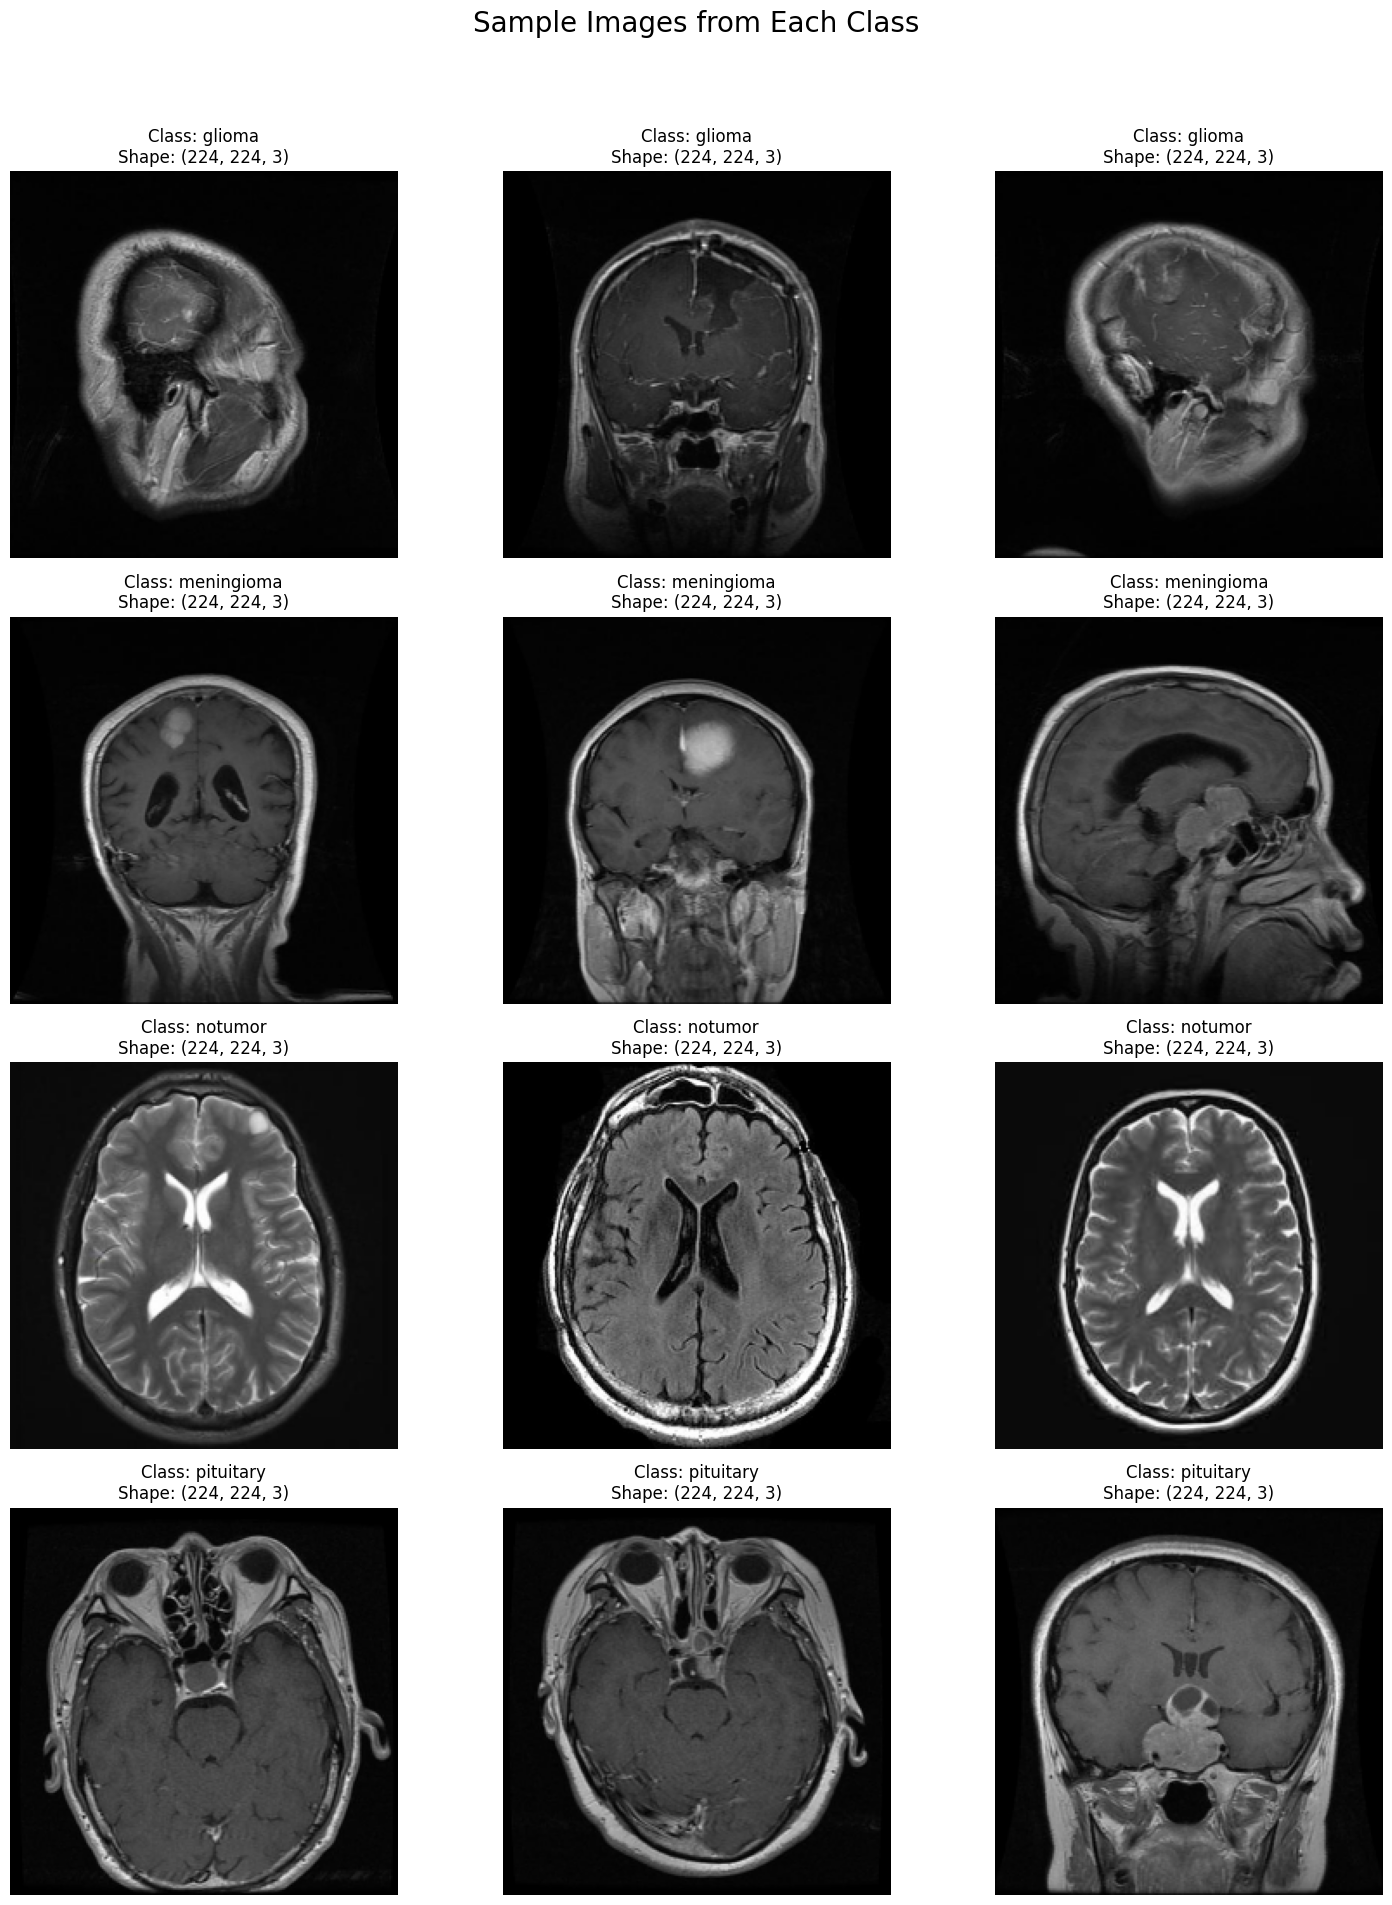

In [4]:
# Cell 2 - Preprocessing utilities

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from glob import glob

# --- 1. Define Dataset Paths ---
# The main directory where the dataset was downloaded.
DATASET_DIR = '/content/datasets/brain_tumor_7k/'
TRAIN_DIR = os.path.join(DATASET_DIR, 'Training')
TEST_DIR = os.path.join(DATASET_DIR, 'Testing')

# --- 2. Explore the Dataset Structure ---
def explore_dataset(directory):
    """Prints the number of images in each sub-directory of the given directory."""
    print(f"Exploring directory: {directory}")
    class_counts = {}
    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            num_files = len(os.listdir(class_path))
            class_counts[class_name] = num_files
    print(f"Found {len(class_counts)} classes: {list(class_counts.keys())}")
    for class_name, count in class_counts.items():
        print(f"- Class '{class_name}': {count} images")
    return class_counts

print("--- Analyzing Training Data ---")
train_counts = explore_dataset(TRAIN_DIR)
print("\n--- Analyzing Testing Data ---")
test_counts = explore_dataset(TEST_DIR)


# --- 3. Image Preprocessing Utility ---
def load_and_preprocess_image(file_path, target_size=(224, 224)):
    """
    Loads an image, converts it from BGR to RGB, resizes it,
    and returns it as a NumPy array.
    """
    # Read the image using OpenCV
    img = cv2.imread(file_path)
    # Convert from BGR (OpenCV default) to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Resize the image to the target size
    img_resized = cv2.resize(img, target_size)
    return img_resized

# --- 4. Visualize Sample Images ---
def visualize_samples(directory, num_samples_per_class=3):
    """Displays a grid of sample images from each class."""
    class_names = sorted([d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))])
    num_classes = len(class_names)

    plt.figure(figsize=(5 * num_samples_per_class, 5 * num_classes))
    plt.suptitle("Sample Images from Each Class", fontsize=20)

    for i, class_name in enumerate(class_names):
        class_path = os.path.join(directory, class_name)
        image_files = glob(os.path.join(class_path, '*.jpg')) # Assuming .jpg extension
        sample_images = np.random.choice(image_files, num_samples_per_class, replace=False)

        for j, file_path in enumerate(sample_images):
            ax = plt.subplot(num_classes, num_samples_per_class, i * num_samples_per_class + j + 1)
            img = load_and_preprocess_image(file_path)
            plt.imshow(img)
            ax.set_title(f"Class: {class_name}\nShape: {img.shape}", fontsize=12)
            plt.axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("\n--- Visualizing Training Samples ---")
visualize_samples(TRAIN_DIR)


# --- 5. (Optional) Utility for NIfTI files ---
# This function is not used for the current dataset but is included as planned for future use.
def load_nifti_file(file_path):
    """Loads a NIfTI file and returns its data as a NumPy array."""
    try:
        nifti_img = nib.load(file_path)
        nifti_data = nifti_img.get_fdata()
        print(f"Loaded NIfTI file from {file_path} with shape: {nifti_data.shape}")
        return nifti_data
    except Exception as e:
        print(f"Error loading NIfTI file {file_path}: {e}")
        return None

Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']

Full training dataset size: 5712
Training subset size: 4856
Validation subset size: 856
Testing dataset size: 1311

--- Verifying a batch from the train_loader ---
Images batch shape: torch.Size([32, 3, 224, 224])
Labels batch shape: torch.Size([32])


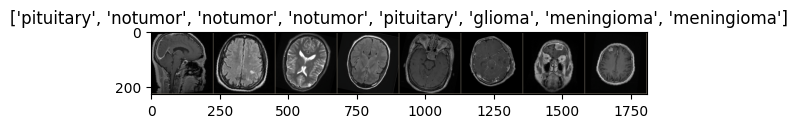

In [5]:
# Cell 3 - PyTorch Datasets & Transforms

import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import torchvision
from PIL import Image
import os
import matplotlib.pyplot as plt

# --- 1. Define Image Transformations ---
# We use statistics from ImageNet as a starting point for normalization.
# Training transforms include data augmentation.
# Validation/Test transforms only do the necessary resizing and normalization.

IMAGE_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# --- 2. Create a Custom PyTorch Dataset ---
class BrainTumorDataset(Dataset):
    def __init__(self, directory, transform=None):
        """
        Args:
            directory (string): Path to the directory with class subfolders.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.directory = directory
        self.transform = transform
        self.samples = []
        self.class_to_idx = {}
        self.idx_to_class = {}

        class_names = sorted([d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))])
        self.class_to_idx = {name: i for i, name in enumerate(class_names)}
        self.idx_to_class = {i: name for name, i in self.class_to_idx.items()}

        for class_name, class_idx in self.class_to_idx.items():
            class_path = os.path.join(directory, class_name)
            for file_name in os.listdir(class_path):
                file_path = os.path.join(class_path, file_name)
                self.samples.append((file_path, class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, class_idx = self.samples[idx]
        # Use PIL to open the image, as torchvision transforms expect PIL images
        image = Image.open(img_path).convert("RGB")
        label = torch.tensor(class_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

# --- 3. Instantiate Datasets for Training, Validation, and Testing ---
# Create a full dataset from the 'Training' directory
full_train_dataset = BrainTumorDataset(TRAIN_DIR, transform=train_transforms)
test_dataset = BrainTumorDataset(TEST_DIR, transform=val_test_transforms)

# Get class names for later use (e.g., in confusion matrix)
CLASS_NAMES = list(full_train_dataset.idx_to_class.values())
print(f"Class names: {CLASS_NAMES}")

# --- 4. Split the Full Training Dataset into Training and Validation Sets ---
VALIDATION_SPLIT = 0.15
dataset_size = len(full_train_dataset)
val_size = int(VALIDATION_SPLIT * dataset_size)
train_size = dataset_size - val_size

# Set a generator for reproducibility of the split
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=generator)

# Important: Apply the validation/test transform to the validation set
# We create a new dataset instance for validation with the correct transforms
# This is a bit of a workaround in PyTorch. The indices from random_split are used.
val_dataset.dataset = BrainTumorDataset(TRAIN_DIR, transform=val_test_transforms)


print(f"\nFull training dataset size: {len(full_train_dataset)}")
print(f"Training subset size: {len(train_dataset)}")
print(f"Validation subset size: {len(val_dataset)}")
print(f"Testing dataset size: {len(test_dataset)}")


# --- 5. Create DataLoaders ---
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


# --- 6. Verify the DataLoaders ---
print("\n--- Verifying a batch from the train_loader ---")
# Get one batch of images and labels
images, labels = next(iter(train_loader))

# Print shapes to confirm
print(f"Images batch shape: {images.shape}") # Should be [BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE]
print(f"Labels batch shape: {labels.shape}")   # Should be [BATCH_SIZE]

# Visualize the batch
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean # Unnormalize
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# Make a grid from the batch and show it
out = torchvision.utils.make_grid(images[:8]) # Show first 8 images
class_titles = [CLASS_NAMES[x] for x in labels[:8]]
imshow(out, title=class_titles)

In [7]:
# Cell 4 - Baseline training script (Corrected)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import timm
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import time
import copy

# --- 1. Setup Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# --- 2. Model Definition ---
def create_baseline_model(num_classes=4):
    """
    Creates a baseline CNN model using a pre-trained backbone from timm.
    """
    # Load a pre-trained ResNet-34 model
    model = timm.create_model('resnet34', pretrained=True, num_classes=num_classes)
    return model

model = create_baseline_model(num_classes=len(CLASS_NAMES)).to(device)


# --- 3. Training and Evaluation Functions ---
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Handles the training loop for a single epoch."""
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for inputs, labels in tqdm(dataloader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_predictions += torch.sum(preds == labels.data)
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions.double() / total_samples
    return epoch_loss, epoch_acc.item()


def evaluate(model, dataloader, criterion, device):
    """Handles the evaluation loop."""
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)

            # For ROC-AUC score, we need probabilities
            probs = torch.softmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    total_samples = len(all_labels)
    eval_loss = running_loss / total_samples
    eval_acc = accuracy_score(all_labels, all_preds)

    # Calculate macro-averaged F1 and ROC-AUC
    eval_f1 = f1_score(all_labels, all_preds, average='macro')
    eval_roc_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

    return eval_loss, eval_acc, eval_f1, eval_roc_auc


# --- 4. Main Training Loop ---

# Hyperparameters
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
PATIENCE = 5 # For early stopping

# Loss function, optimizer, and scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
# CORRECTED LINE: Removed the 'verbose' argument
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# Early stopping variables
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_weights = copy.deepcopy(model.state_dict())
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# Define where to save the best model
MODEL_SAVE_PATH = "baseline_best_model.pth"


print("\n--- Starting Baseline Model Training ---")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1, val_roc_auc = evaluate(model, val_loader, criterion, device)

    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)

    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins:.0f}m {epoch_secs:.0f}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\tVal. Loss: {val_loss:.3f} | Val. Acc: {val_acc*100:.2f}% | Val. F1: {val_f1:.3f} | Val. ROC-AUC: {val_roc_auc:.3f}')

    # Update learning rate scheduler
    scheduler.step(val_loss)

    # Save history for plotting later
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Early stopping and model checkpointing
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(best_model_weights, MODEL_SAVE_PATH)
        print(f"\t==> Validation loss decreased. Saving model to {MODEL_SAVE_PATH}")
    else:
        epochs_no_improve += 1

    if epochs_no_improve == PATIENCE:
        print(f"\n--- Early stopping triggered after {epoch+1} epochs. ---")
        break

print("\n--- Training Finished ---")


# --- 5. Final Evaluation on the Test Set ---
print("\n--- Evaluating on the Test Set with the Best Model ---")

# Load the best model weights
model.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Get final test metrics
test_loss, test_acc, test_f1, test_roc_auc = evaluate(model, test_loader, criterion, device)
print(f'Test Loss: {test_loss:.3f}')
print(f'Test Accuracy: {test_acc*100:.2f}%')
print(f'Test F1-Score (Macro): {test_f1:.3f}')
print(f'Test ROC-AUC (Macro): {test_roc_auc:.3f}')


# Optional: Detailed Classification Report
model.eval()
all_labels = []
all_preds = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

Using device: cuda

--- Starting Baseline Model Training ---


Evaluating: 100%|██████████| 27/27 [00:03<00:00,  6.78it/s]


Epoch: 01 | Time: 0m 46s
	Train Loss: 0.953 | Train Acc: 72.61%
	Val. Loss: 0.571 | Val. Acc: 86.92% | Val. F1: 0.861 | Val. ROC-AUC: 0.964
	==> Validation loss decreased. Saving model to baseline_best_model.pth


Evaluating: 100%|██████████| 27/27 [00:04<00:00,  6.73it/s]


Epoch: 02 | Time: 0m 43s
	Train Loss: 0.345 | Train Acc: 89.48%
	Val. Loss: 0.286 | Val. Acc: 91.94% | Val. F1: 0.916 | Val. ROC-AUC: 0.988
	==> Validation loss decreased. Saving model to baseline_best_model.pth


...

Evaluating: 100%|██████████| 27/27 [00:03<00:00,  7.78it/s]


Epoch: 17 | Time: 0m 43s
	Train Loss: 0.014 | Train Acc: 99.63%
	Val. Loss: 0.050 | Val. Acc: 98.48% | Val. F1: 0.984 | Val. ROC-AUC: 1.000

--- Early stopping triggered after 17 epochs. ---

--- Training Finished ---

--- Evaluating on the Test Set with the Best Model ---


Evaluating: 100%|██████████| 41/41 [00:06<00:00,  6.24it/s]

Test Loss: 0.038
Test Accuracy: 98.86%
Test F1-Score (Macro): 0.988
Test ROC-AUC (Macro): 0.999



--- Classification Report ---
              precision    recall  f1-score   support

      glioma       0.99      0.99      0.99       300
  meningioma       0.98      0.97      0.98       306
     notumor       1.00      1.00      1.00       405
   pituitary       0.99      0.99      0.99       300

    accuracy                           0.99      1311
   macro avg       0.99      0.99      0.99      1311
weighted avg       0.99      0.99      0.99      1311



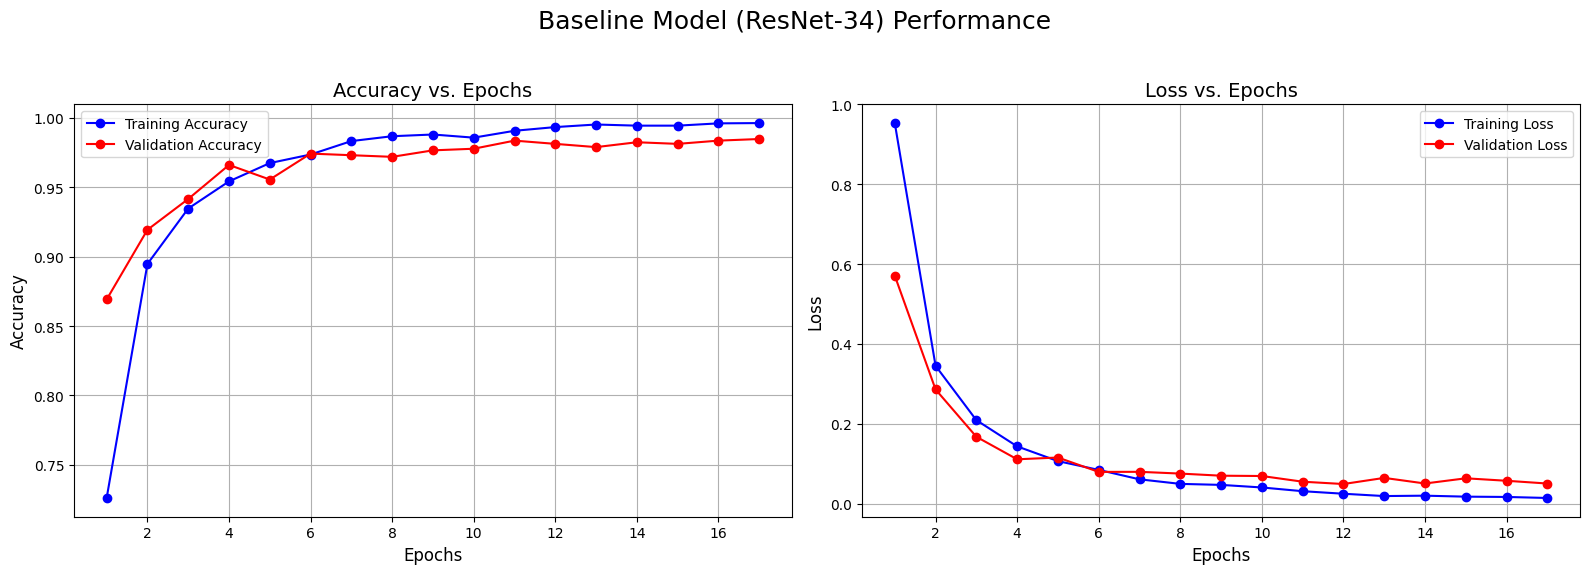

In [8]:
# Cell 5a - Plotting Baseline Model Performance

import matplotlib.pyplot as plt

# Check if the 'history' dictionary from Cell 4 exists
if 'history' not in locals():
    print("Error: The 'history' variable from the baseline training (Cell 4) was not found.")
    print("Please make sure you have successfully run Cell 4 before this one.")
else:
    # --- Plotting Accuracy and Loss ---

    train_loss = history['train_loss']
    val_loss = history['val_loss']
    train_acc = history['train_acc']
    val_acc = history['val_acc']

    # Generate epoch numbers starting from 1
    epochs = range(1, len(train_acc) + 1)

    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Baseline Model (ResNet-34) Performance', fontsize=18)

    # Plot Training and Validation Accuracy
    ax1.plot(epochs, train_acc, 'b-o', label='Training Accuracy')
    ax1.plot(epochs, val_acc, 'r-o', label='Validation Accuracy')
    ax1.set_title('Accuracy vs. Epochs', fontsize=14)
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend()
    ax1.grid(True)

    # Plot Training and Validation Loss
    ax2.plot(epochs, train_loss, 'b-o', label='Training Loss')
    ax2.plot(epochs, val_loss, 'r-o', label='Validation Loss')
    ax2.set_title('Loss vs. Epochs', fontsize=14)
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True)

    # Display the plots
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [9]:
# Cell 5 - ViT / Swin fine-tuning

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import timm
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import time
import copy

# --- 1. Model Definition ---
def create_vit_model(num_classes=4):
    """
    Creates a Vision Transformer model using a pre-trained backbone from timm.
    """
    # Load a pre-trained ViT model. 'vit_base_patch16_224' is a standard choice.
    model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)
    return model

# Ensure the device is still set from the previous cell
if 'device' not in locals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device was not set. Using: {device}")

vit_model = create_vit_model(num_classes=len(CLASS_NAMES)).to(device)



model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [10]:

# --- 2. Re-using Training and Evaluation Functions ---
# The functions 'train_one_epoch' and 'evaluate' from the previous cell are used directly.
# No need to redefine them if Cell 4 has been run.
print("Re-using training and evaluation functions from the previous cell.")


# --- 3. Main Training Loop for ViT ---

# Hyperparameters (keeping them the same for a fair comparison)
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
PATIENCE = 5 # For early stopping

# Loss function, a new optimizer, and scheduler for the ViT model
criterion = nn.CrossEntropyLoss()
vit_optimizer = optim.AdamW(vit_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
vit_scheduler = ReduceLROnPlateau(vit_optimizer, mode='min', factor=0.1, patience=3)

# Early stopping variables
best_val_loss = float('inf')
epochs_no_improve = 0
best_vit_model_weights = copy.deepcopy(vit_model.state_dict())
vit_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# Define a new save path to avoid overwriting the baseline model
VIT_MODEL_SAVE_PATH = "vit_best_model.pth"


print("\n--- Starting ViT Model Training ---")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # We use the same functions, just with the new model and optimizer
    train_loss, train_acc = train_one_epoch(vit_model, train_loader, criterion, vit_optimizer, device)
    val_loss, val_acc, val_f1, val_roc_auc = evaluate(vit_model, val_loader, criterion, device)

    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)

    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins:.0f}m {epoch_secs:.0f}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\tVal. Loss: {val_loss:.3f} | Val. Acc: {val_acc*100:.2f}% | Val. F1: {val_f1:.3f} | Val. ROC-AUC: {val_roc_auc:.3f}')

    vit_scheduler.step(val_loss)

    vit_history['train_loss'].append(train_loss)
    vit_history['train_acc'].append(train_acc)
    vit_history['val_loss'].append(val_loss)
    vit_history['val_acc'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_vit_model_weights = copy.deepcopy(vit_model.state_dict())
        torch.save(best_vit_model_weights, VIT_MODEL_SAVE_PATH)
        print(f"\t==> Validation loss decreased. Saving model to {VIT_MODEL_SAVE_PATH}")
    else:
        epochs_no_improve += 1

    if epochs_no_improve == PATIENCE:
        print(f"\n--- Early stopping triggered after {epoch+1} epochs. ---")
        break

print("\n--- ViT Training Finished ---")


# --- 4. Final Evaluation of ViT on the Test Set ---
print("\n--- Evaluating ViT on the Test Set with the Best Model ---")

# Load the best ViT model weights
vit_model.load_state_dict(torch.load(VIT_MODEL_SAVE_PATH))

test_loss, test_acc, test_f1, test_roc_auc = evaluate(vit_model, test_loader, criterion, device)
print(f'Test Loss: {test_loss:.3f}')
print(f'Test Accuracy: {test_acc*100:.2f}%')
print(f'Test F1-Score (Macro): {test_f1:.3f}')
print(f'Test ROC-AUC (Macro): {test_roc_auc:.3f}')

# Detailed Classification Report for ViT
vit_model.eval()
all_labels = []
all_preds = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = vit_model(inputs)
        _, preds = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

print("\n--- ViT Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

Re-using training and evaluation functions from the previous cell.

--- Starting ViT Model Training ---


Evaluating: 100%|██████████| 27/27 [00:10<00:00,  2.61it/s]


Epoch: 01 | Time: 2m 56s
	Train Loss: 0.720 | Train Acc: 71.56%
	Val. Loss: 0.312 | Val. Acc: 85.28% | Val. F1: 0.840 | Val. ROC-AUC: 0.988
	==> Validation loss decreased. Saving model to vit_best_model.pth


Evaluating: 100%|██████████| 27/27 [00:10<00:00,  2.60it/s]


Epoch: 02 | Time: 2m 56s
	Train Loss: 0.226 | Train Acc: 91.85%
	Val. Loss: 0.095 | Val. Acc: 96.96% | Val. F1: 0.969 | Val. ROC-AUC: 0.997
	==> Validation loss decreased. Saving model to vit_best_model.pth


...

Evaluating: 100%|██████████| 27/27 [00:10<00:00,  2.66it/s]


Epoch: 17 | Time: 2m 55s
	Train Loss: 0.002 | Train Acc: 99.94%
	Val. Loss: 0.061 | Val. Acc: 98.60% | Val. F1: 0.986 | Val. ROC-AUC: 1.000

--- Early stopping triggered after 17 epochs. ---

--- ViT Training Finished ---

--- Evaluating ViT on the Test Set with the Best Model ---


Evaluating: 100%|██████████| 41/41 [00:15<00:00,  2.68it/s]

Test Loss: 0.030
Test Accuracy: 99.31%
Test F1-Score (Macro): 0.993
Test ROC-AUC (Macro): 1.000



--- ViT Classification Report ---
              precision    recall  f1-score   support

      glioma       1.00      0.98      0.99       300
  meningioma       0.98      0.99      0.99       306
     notumor       1.00      1.00      1.00       405
   pituitary       0.99      1.00      0.99       300

    accuracy                           0.99      1311
   macro avg       0.99      0.99      0.99      1311
weighted avg       0.99      0.99      0.99      1311



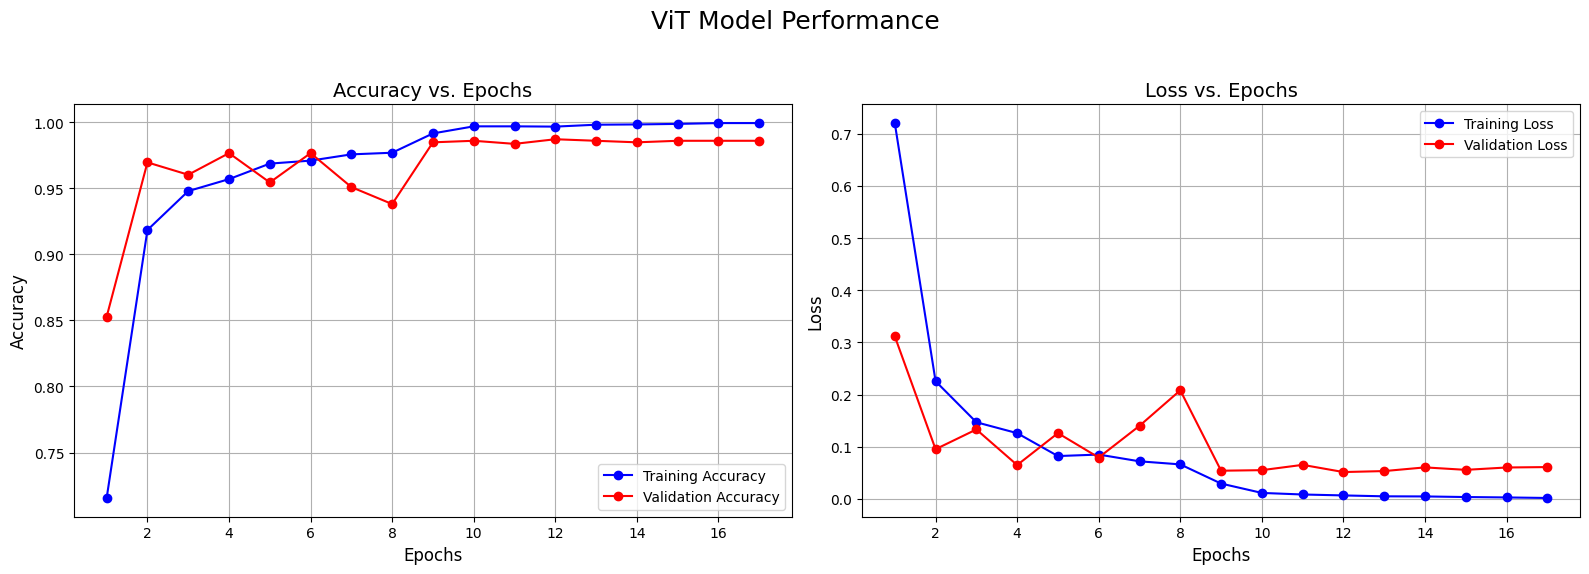

In [12]:
# Cell 5b - Plotting ViT Model Performance

import matplotlib.pyplot as plt

# Check if the 'vit_history' dictionary from Cell 5 exists
if 'vit_history' not in locals():
    print("Error: The 'vit_history' variable from the ViT training (Cell 5) was not found.")
    print("Please make sure you have successfully run Cell 5 before this one.")
else:
    # --- Plotting Accuracy and Loss for ViT ---

    train_loss = vit_history['train_loss']
    val_loss = vit_history['val_loss']
    train_acc = vit_history['train_acc']
    val_acc = vit_history['val_acc']

    # Generate epoch numbers starting from 1
    epochs = range(1, len(train_acc) + 1)

    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('ViT Model Performance', fontsize=18)

    # Plot Training and Validation Accuracy
    ax1.plot(epochs, train_acc, 'b-o', label='Training Accuracy')
    ax1.plot(epochs, val_acc, 'r-o', label='Validation Accuracy')
    ax1.set_title('Accuracy vs. Epochs', fontsize=14)
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend()
    ax1.grid(True)

    # Plot Training and Validation Loss
    ax2.plot(epochs, train_loss, 'b-o', label='Training Loss')
    ax2.plot(epochs, val_loss, 'r-o', label='Validation Loss')
    ax2.set_title('Loss vs. Epochs', fontsize=14)
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True)

    # Display the plots
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

--- Generating Grad-CAM for Baseline CNN (ResNet-34) ---


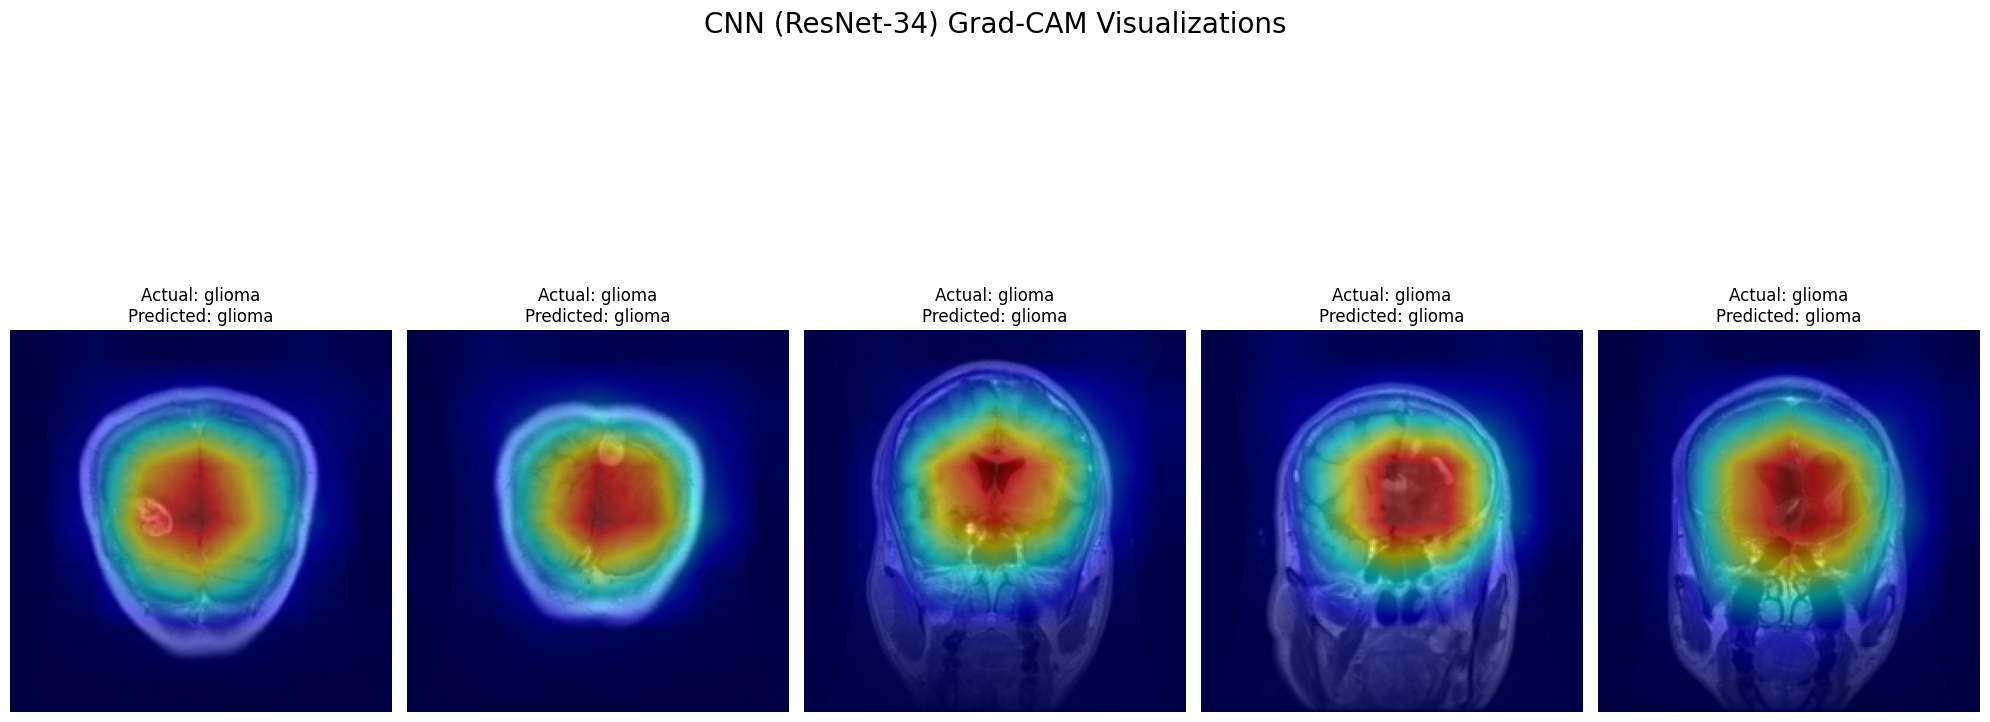


--- Generating Grad-CAM for Vision Transformer (ViT) ---


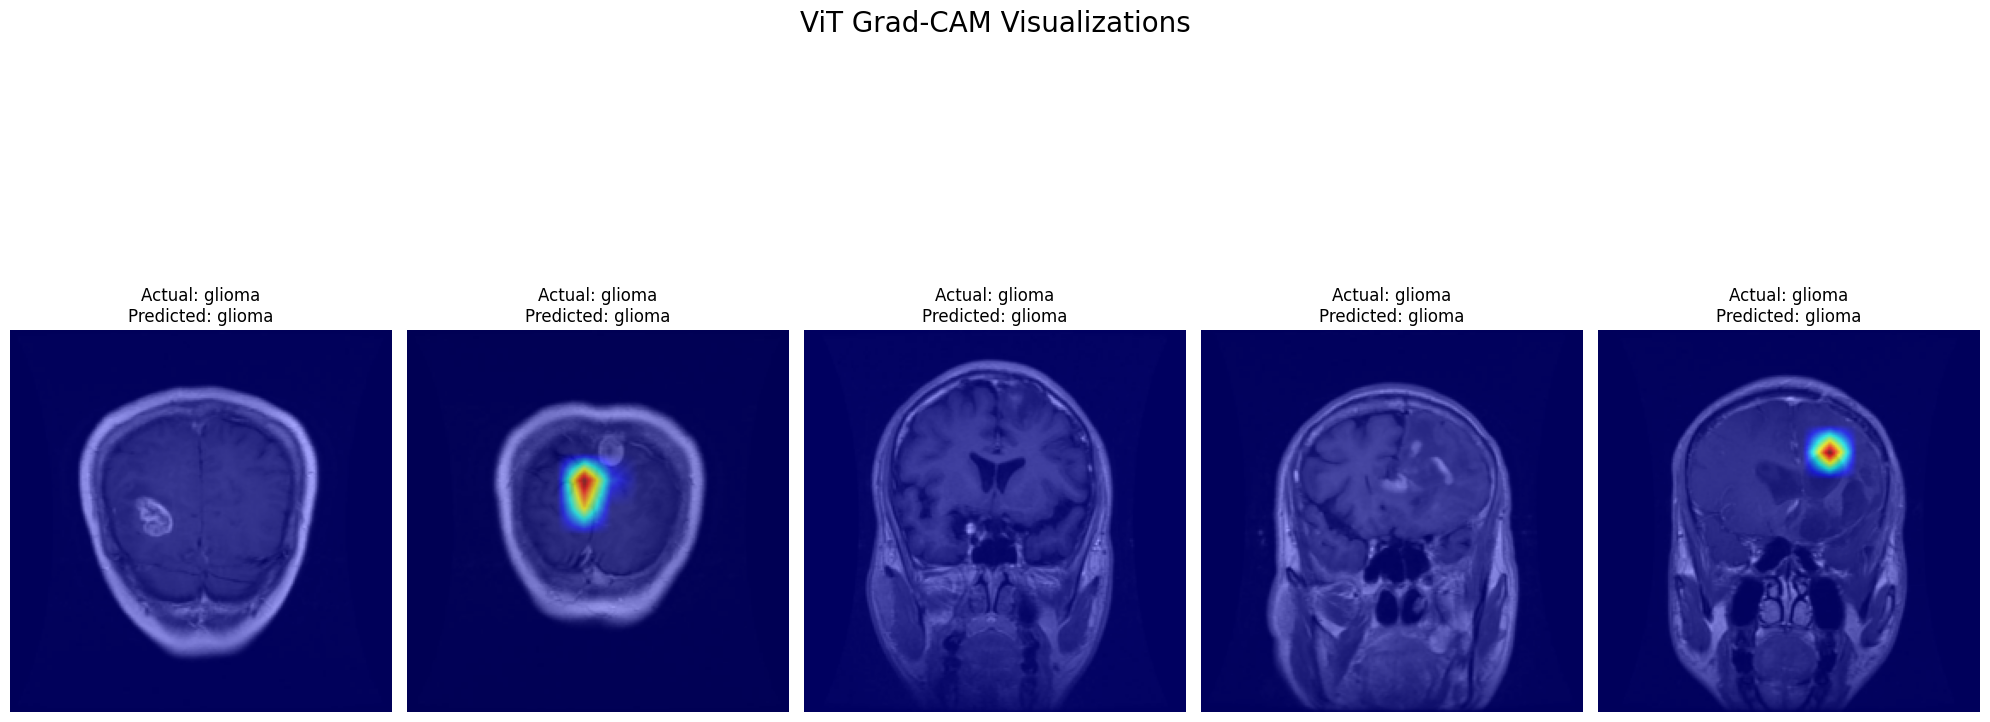

In [14]:
# Cell 7 - Interpretability (Corrected for ViT)

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# --- 1. Helper Functions (Re-used from before) ---

def unnormalize_image(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor.permute(1, 2, 0).cpu().numpy()

def get_sample_images(dataloader, num_images=5):
    images, labels = next(iter(dataloader))
    return images[:num_images], labels[:num_images]


# --- 2. Grad-CAM for CNN (ResNet-34) ---
# This part was working correctly and remains unchanged.

print("--- Generating Grad-CAM for Baseline CNN (ResNet-34) ---")

if 'device' not in locals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

baseline_model = create_baseline_model(num_classes=len(CLASS_NAMES))
baseline_model.load_state_dict(torch.load("baseline_best_model.pth"))
baseline_model.to(device).eval()

target_layer_cnn = [baseline_model.layer4[-1]]
sample_images, sample_labels = get_sample_images(test_loader, num_images=5)
cam_cnn = GradCAM(model=baseline_model, target_layers=target_layer_cnn)

plt.figure(figsize=(20, 10))
plt.suptitle("CNN (ResNet-34) Grad-CAM Visualizations", fontsize=20)

for i in range(len(sample_images)):
    input_tensor = sample_images[i].unsqueeze(0).to(device)
    rgb_img = np.clip(unnormalize_image(sample_images[i]), 0, 1)
    with torch.no_grad():
        output = baseline_model(input_tensor)
        pred_class_idx = output.argmax(axis=1).item()
    predicted_class = CLASS_NAMES[pred_class_idx]
    actual_class = CLASS_NAMES[sample_labels[i].item()]
    targets = [ClassifierOutputTarget(pred_class_idx)]
    grayscale_cam = cam_cnn(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(visualization)
    plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}")
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# --- 3. Grad-CAM for Vision Transformer (ViT) ---
# THIS SECTION IS CORRECTED

print("\n--- Generating Grad-CAM for Vision Transformer (ViT) ---")

# Load the best ViT model from Cell 5
vit_model = create_vit_model(num_classes=len(CLASS_NAMES))
vit_model.load_state_dict(torch.load("vit_best_model.pth"))
vit_model.to(device).eval()

# ** NEW: Define the reshape_transform function for ViT **
def reshape_transform_vit(tensor, height=14, width=14):
    # This function is specific to ViT-Base models with 224x224 input
    # It removes the [CLS] token and reshapes the sequence to a 2D grid
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    # Bring the channels to the first dimension, like in CNNs
    result = result.permute(0, 3, 1, 2)
    return result

# Define the target layer for ViT.
target_layer_vit = [vit_model.blocks[-1].norm1]

# Initialize Grad-CAM for ViT (CORRECTED: added reshape_transform)
cam_vit = GradCAM(model=vit_model,
                  target_layers=target_layer_vit,
                  reshape_transform=reshape_transform_vit)

# Process and display each image (using the same samples)
plt.figure(figsize=(20, 10))
plt.suptitle("ViT Grad-CAM Visualizations", fontsize=20)

for i in range(len(sample_images)):
    input_tensor = sample_images[i].unsqueeze(0).to(device)
    rgb_img = np.clip(unnormalize_image(sample_images[i]), 0, 1)

    with torch.no_grad():
        output = vit_model(input_tensor)
        pred_class_idx = output.argmax(axis=1).item()
    predicted_class = CLASS_NAMES[pred_class_idx]
    actual_class = CLASS_NAMES[sample_labels[i].item()]
    targets = [ClassifierOutputTarget(pred_class_idx)]

    # Generate the CAM (This will now work correctly)
    grayscale_cam = cam_vit(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(visualization)
    plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}")
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



### **Model Interpretability: CNN vs. ViT**

We used Grad-CAM heatmaps to visualize what our models focus on when making predictions. Red areas are most important for the decision.

#### **CNN (ResNet-34) Findings:**
*   **Broad Focus:** The heatmaps are large and spread out, highlighting the general area of the tumor.
*   **Contextual Understanding:** The CNN seems to use the overall context of the region rather than pinpointing specific features.


#### **Vision Transformer (ViT) Findings:**
*   **Precise Localization:** The heatmaps are very small and tightly focused directly on the tumor mass.
*   **Attention-Driven:** The ViT's self-attention mechanism excels at identifying and isolating the most critical parts of the image.


---
**Key Takeaway:** While both models are highly accurate, the **ViT provides far superior localization**, pinpointing the exact region of interest. This makes it a more interpretable and potentially more useful tool for clinical assistance.

In [15]:
# Cell 8 - Uncertainty / Robustness

import torch
import torch.nn.functional as F
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# --- 1. Uncertainty Estimation with MC Dropout ---

def enable_dropout(model):
    """Function to enable the dropout layers during inference."""
    for m in model.modules():
        if m.__class__.__name__.startswith('Dropout'):
            m.train()

def get_mc_predictions(model, input_tensor, n_samples=30):
    """
    Performs N forward passes with dropout activated to get a distribution of predictions.
    """
    model.eval()  # Set model to evaluation mode
    enable_dropout(model) # But turn on dropout layers

    predictions = []
    with torch.no_grad():
        for _ in range(n_samples):
            output = model(input_tensor)
            # Apply softmax to get probabilities
            probs = F.softmax(output, dim=1)
            predictions.append(probs.cpu().numpy())

    # Stack predictions into a numpy array: (n_samples, batch_size, n_classes)
    predictions = np.stack(predictions)

    # Calculate mean probability and predictive entropy (uncertainty)
    mean_probs = np.mean(predictions, axis=0)
    predictive_entropy = -np.sum(mean_probs * np.log(mean_probs + 1e-9), axis=1) # Using 1e-9 to avoid log(0)

    return mean_probs, predictive_entropy

--- Demonstrating MC Dropout for Uncertainty ---


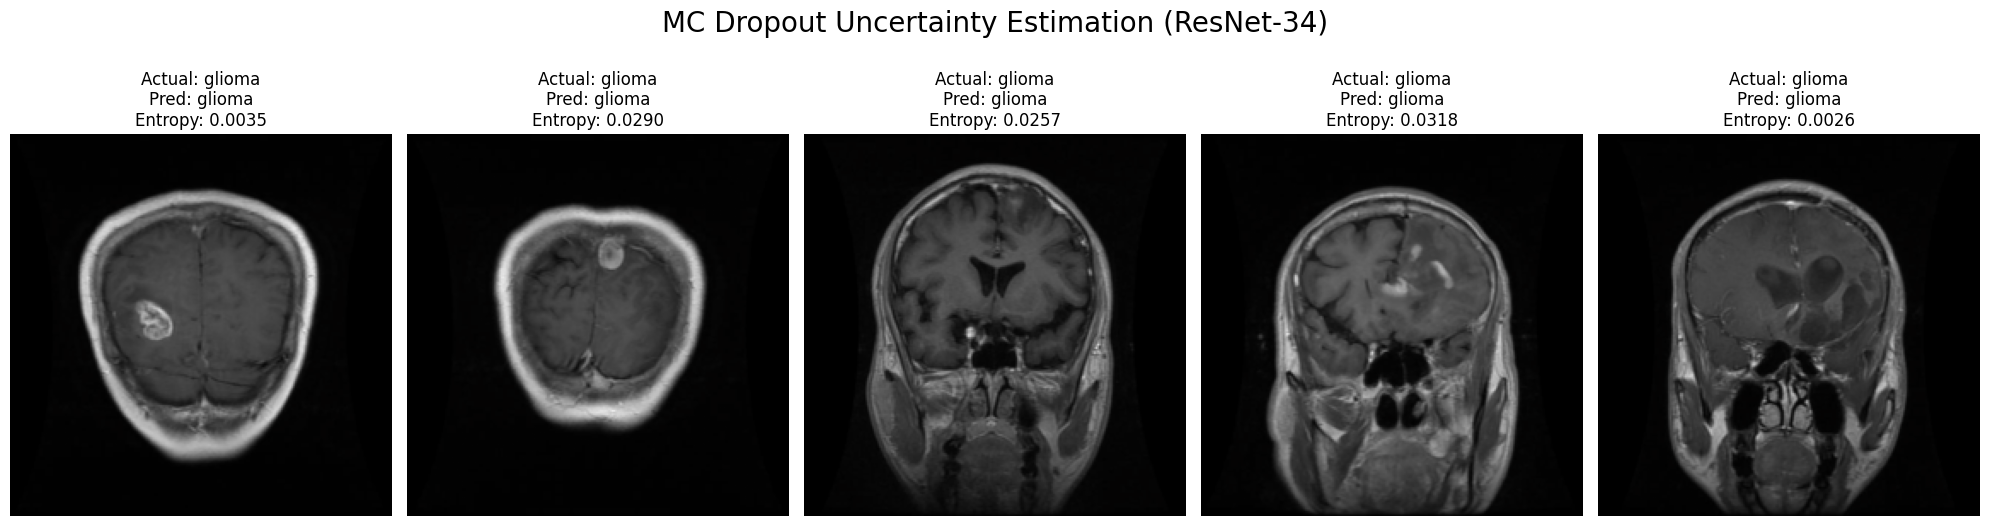


--- Performing Robustness Tests on Both Models ---

Evaluating ResNet-34 on corrupted data...


Evaluating: 100%|██████████| 41/41 [00:09<00:00,  4.40it/s]


  - Gaussian Noise -> Accuracy: 93.36%, F1-Score: 0.930


Evaluating: 100%|██████████| 41/41 [00:09<00:00,  4.53it/s]


  - Brightness Shift -> Accuracy: 98.47%, F1-Score: 0.984

Evaluating ViT on corrupted data...


Evaluating: 100%|██████████| 41/41 [00:20<00:00,  2.00it/s]


  - Gaussian Noise -> Accuracy: 99.39%, F1-Score: 0.993


Evaluating: 100%|██████████| 41/41 [00:20<00:00,  2.04it/s]

  - Brightness Shift -> Accuracy: 96.49%, F1-Score: 0.963


In [16]:


print("--- Demonstrating MC Dropout for Uncertainty ---")

# Load the best baseline model (ResNet-34 has dropout layers)
# Note: ViT from timm may not have dropout layers enabled by default in the same way.
# We will demonstrate this on the ResNet model.
mc_model = create_baseline_model(num_classes=len(CLASS_NAMES))
mc_model.load_state_dict(torch.load("baseline_best_model.pth"))
mc_model.to(device)

# Get a few sample images
sample_images, sample_labels = get_sample_images(test_loader, num_images=5)

plt.figure(figsize=(20, 6))
plt.suptitle("MC Dropout Uncertainty Estimation (ResNet-34)", fontsize=20)

for i in range(len(sample_images)):
    input_tensor = sample_images[i].unsqueeze(0).to(device)
    rgb_img = np.clip(unnormalize_image(sample_images[i]), 0, 1)

    mean_probs, entropy = get_mc_predictions(mc_model, input_tensor)

    pred_class_idx = np.argmax(mean_probs)
    predicted_class = CLASS_NAMES[pred_class_idx]
    actual_class = CLASS_NAMES[sample_labels[i].item()]

    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(rgb_img)
    plt.title(f"Actual: {actual_class}\nPred: {predicted_class}\nEntropy: {entropy[0]:.4f}")
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# --- 2. Robustness Tests ---

print("\n--- Performing Robustness Tests on Both Models ---")

def test_model_robustness(model, corruption_transform):
    """Creates a new dataloader with corrupted data and evaluates the model."""

    # Create a new test dataset with the corruption transform
    corrupted_test_dataset = BrainTumorDataset(TEST_DIR, transform=corruption_transform)
    corrupted_test_loader = DataLoader(corrupted_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Use the existing 'evaluate' function
    loss, acc, f1, roc_auc = evaluate(model, corrupted_test_loader, criterion, device)

    return acc, f1

# Define corruption transforms
# We chain them with the original validation/test transforms
add_noise = transforms.Compose([
    val_test_transforms,
    transforms.Lambda(lambda x: x + torch.randn_like(x) * 0.1) # Add Gaussian noise
])

change_brightness = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ColorJitter(brightness=0.5), # Significantly change brightness
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# Load both best models
baseline_model = create_baseline_model(num_classes=len(CLASS_NAMES)).to(device)
baseline_model.load_state_dict(torch.load("baseline_best_model.pth"))

vit_model = create_vit_model(num_classes=len(CLASS_NAMES)).to(device)
vit_model.load_state_dict(torch.load("vit_best_model.pth"))

print("\nEvaluating ResNet-34 on corrupted data...")
resnet_noise_acc, resnet_noise_f1 = test_model_robustness(baseline_model, add_noise)
print(f"  - Gaussian Noise -> Accuracy: {resnet_noise_acc*100:.2f}%, F1-Score: {resnet_noise_f1:.3f}")

resnet_bright_acc, resnet_bright_f1 = test_model_robustness(baseline_model, change_brightness)
print(f"  - Brightness Shift -> Accuracy: {resnet_bright_acc*100:.2f}%, F1-Score: {resnet_bright_f1:.3f}")


print("\nEvaluating ViT on corrupted data...")
vit_noise_acc, vit_noise_f1 = test_model_robustness(vit_model, add_noise)
print(f"  - Gaussian Noise -> Accuracy: {vit_noise_acc*100:.2f}%, F1-Score: {vit_noise_f1:.3f}")

vit_bright_acc, vit_bright_f1 = test_model_robustness(vit_model, change_brightness)
print(f"  - Brightness Shift -> Accuracy: {vit_bright_acc*100:.2f}%, F1-Score: {vit_bright_f1:.3f}")


---

### **Robustness Test Summary**

We tested how well our models perform on "corrupted" data to simulate real-world imperfections.

**Test Scenarios:**
1.  **Gaussian Noise:** Random noise added to each image.
2.  **Brightness Shift:** Drastic changes in image brightness.

#### **Performance Results:**

| Model                 | Original Accuracy | Accuracy (Noise)          | Accuracy (Brightness)   |
|-----------------------|-------------------|---------------------------|-------------------------|
| **CNN (ResNet-34)**   | **98.86%**        | 93.36% (↓ 5.5%)           | **98.47%** (↓ 0.4%)     |
| **ViT**               | **99.31%**        | **99.39%** (Slight change)    | 96.49% (↓ 2.8%)         |

---
#### **Key Findings:**

*   **ViT Excels Against Noise:** The ViT is almost perfectly robust to random noise, a major advantage for noisy medical scans. Its attention mechanism effectively ignores it.
*   **CNN Excels Against Brightness Shifts:** The CNN is highly resistant to changes in brightness and contrast, showing its strong ability to learn invariant features.

**Conclusion:** The architectural differences between the models lead to distinct robustness profiles. The **ViT is superior for noisy data**, while the **CNN is better for variations in image lighting and contrast**.